In [22]:
import re
import emoji
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from google.colab import drive
from nltk.tokenize import TweetTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from scipy.sparse import hstack
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc as sklearn_auc, roc_auc_score


drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
df = pd.read_csv("/content/drive/MyDrive/CPSC 3810 Final Project/cyberbullying_tweets.csv")

In [24]:
df['cyberbullying_type'].value_counts()

,count
cyberbullying_type,
religion,7998
age,7992
gender,7973
ethnicity,7961
not_cyberbullying,7945
other_cyberbullying,7823


DATASET CLEANING

In [25]:
contractions_dict = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot",
    "can't've": "cannot have", "'cause": "because", "could've": "could have",
    "couldn't": "could not", "couldn't've": "could not have", "didn't": "did not",
    "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hadn't've": "had not have", "hasn't": "has not", "haven't": "have not",
    "he'd": "he would", "he'd've": "he would have", "he'll": "he will",
    "he'll've": "he will have", "he's": "he is", "how'd": "how did",
    "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
    "i'd": "i would", "i'd've": "i would have", "i'll": "i will",
    "i'll've": "i will have", "i'm": "i am", "i've": "i have",
    "isn't": "is not", "it'd": "it would", "it'd've": "it would have",
    "it'll": "it will", "it'll've": "it will have", "it's": "it is",
    "let's": "let us", "ma'am": "madam", "mayn't": "may not",
    "might've": "might have", "mightn't": "might not", "mightn't've": "might not have",
    "must've": "must have", "mustn't": "must not", "mustn't've": "must have"}


def preprocess_tweet(text):
    text = text.lower()
    text = emoji.demojize(text, delimiters=(":", ":"))
    text = re.sub(r'@\S+', '<USER>', text)
    text = re.sub(r'http\S+|https\S+|www\.\S+', '', text)
    text = ' '.join([contractions_dict.get(word, word) for word in text.split()])
    text = re.sub(r'[^\w\s<>:]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [26]:
df['tweet_text'] = df['tweet_text'].apply(preprocess_tweet)
df.dropna(subset=['tweet_text'], inplace=True)
df.drop_duplicates(subset=['tweet_text'], inplace=True)

In [27]:
tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True)
df['tokens'] = df['tweet_text'].apply(tokenizer.tokenize)

In [28]:
classifications = {'not_cyberbullying': 0, 'ethnicity': 1, 'racial': 2, 'gender': 3, 'age': 4, 'religion': 5, 'other_cyberbullying': 6}
df['is_cyberbullying'] = df['cyberbullying_type'].apply(lambda x: classifications[x])

TF-IDF Vectorization

In [29]:
df['clean_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))

vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1,2),min_df = 2,max_df = 0.95)

X = vectorizer.fit_transform(df['clean_text'])
y = df['is_cyberbullying']

### Splitting Data into Training and Testing Sets

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (36205, 5000)
Shape of X_test: (9052, 5000)
Shape of y_train: (36205,)
Shape of y_test: (9052,)


Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.8342
Precision: 0.8388
Recall: 0.8342
F1 Score: 0.8360
Macro AUC: 0.9711


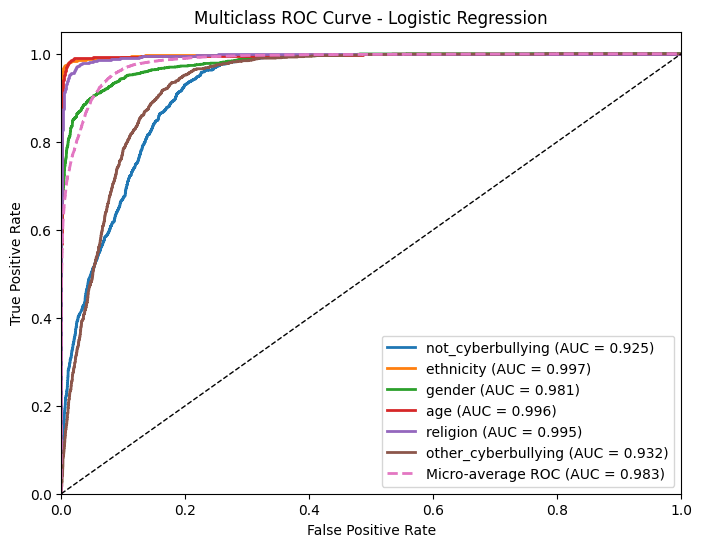

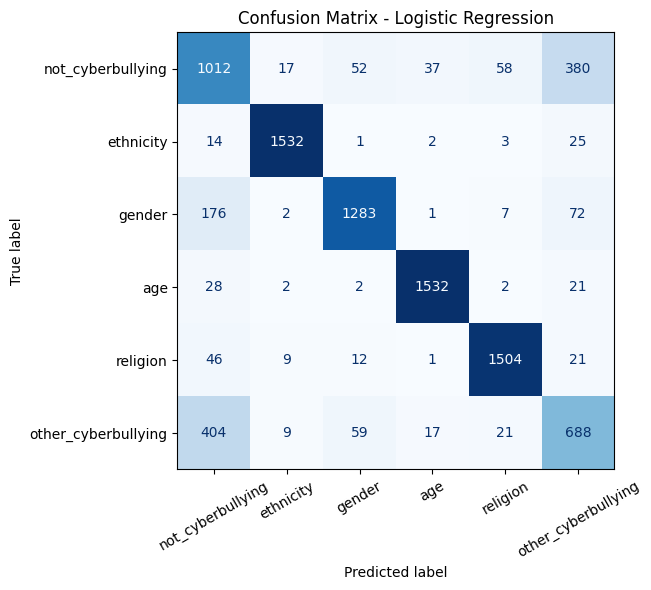

In [31]:
model = LogisticRegression(multi_class='multinomial', max_iter=1000, C=1.0, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

classes = model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
fpr = {}
tpr = {}
roc_auc = {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = sklearn_auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = sklearn_auc(fpr["micro"], tpr["micro"])
macro_auc = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro AUC: {macro_auc:.4f}")

classifications = {'not_cyberbullying': 0, 'ethnicity': 1, 'racial': 2,
                   'gender': 3, 'age': 4, 'religion': 5, 'other_cyberbullying': 6}
class_name_map = {v: k for k, v in classifications.items()}
plt.figure(figsize=(8, 6))


for i in range(len(classes)):
    class_id = classes[i]
    class_label = class_name_map.get(class_id, f"Class {class_id}")

    plt.plot(fpr[i], tpr[i], lw=2, label=f"{class_label} (AUC = {roc_auc[i]:.3f})")


plt.plot(fpr["micro"], tpr["micro"], linestyle="--", lw=2, label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()


cm = confusion_matrix(y_test, y_pred)
display_labels = [class_name_map.get(c, f"Class {c}") for c in classes]
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels).plot(
    ax=ax, cmap="Blues", xticks_rotation=30, colorbar=False)


plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [32]:
STOPWORDS = {
    "i","me","my","myself","we","our","ours","ourselves","you","your","yours",
    "yourself","yourselves","he","him","his","himself","she","her","hers",
    "herself","it","its","itself","they","them","their","theirs","themselves",
    "what","which","who","whom","this","that","these","those","am","is","are",
    "was","were","be","been","being","have","has","had","having","do","does",
    "did","doing","a","an","the","and","but","if","or","because","as","until",
    "while","of","at","by","for","with","about","against","between","into",
    "through","during","before","after","above","below","to","from","up","down",
    "in","out","on","off","over","under","again","further","then","once","here",
    "there","when","where","why","how","all","both","each","few","more","most",
    "other","some","such","no","nor","not","only","own","same","so","than",
    "too","very","s","t","can","will","just","don","should","now","d","ll",
    "m","o","re","ve","y","ain","aren","couldn","didn","doesn","hadn","hasn",
    "haven","isn","ma","mightn","mustn","needn","shan","shouldn","wasn","weren",
    "won","wouldn","rt","via","amp","user","http","https","co","gt","lt","nbsp",
    "get","got","go","going","know","think","want","like","one","would",
    "could","said","say","see","make","come","good","time","day","new",
    "people","u","ur","r","lol","im","dont","im","cant","ive","its","thats",
}

CATEGORY_PALETTE = {
    "not_cyberbullying": "#4C72B0",
    "gender": "#DD8452",
    "religion": "#55A868",
    "other_cyberbullying":"#C44E52",
    "age":"#8172B3",
    "ethnicity":"#937860",
}
CATEGORIES = list(CATEGORY_PALETTE.keys())


### BoW and N-grams Analysis

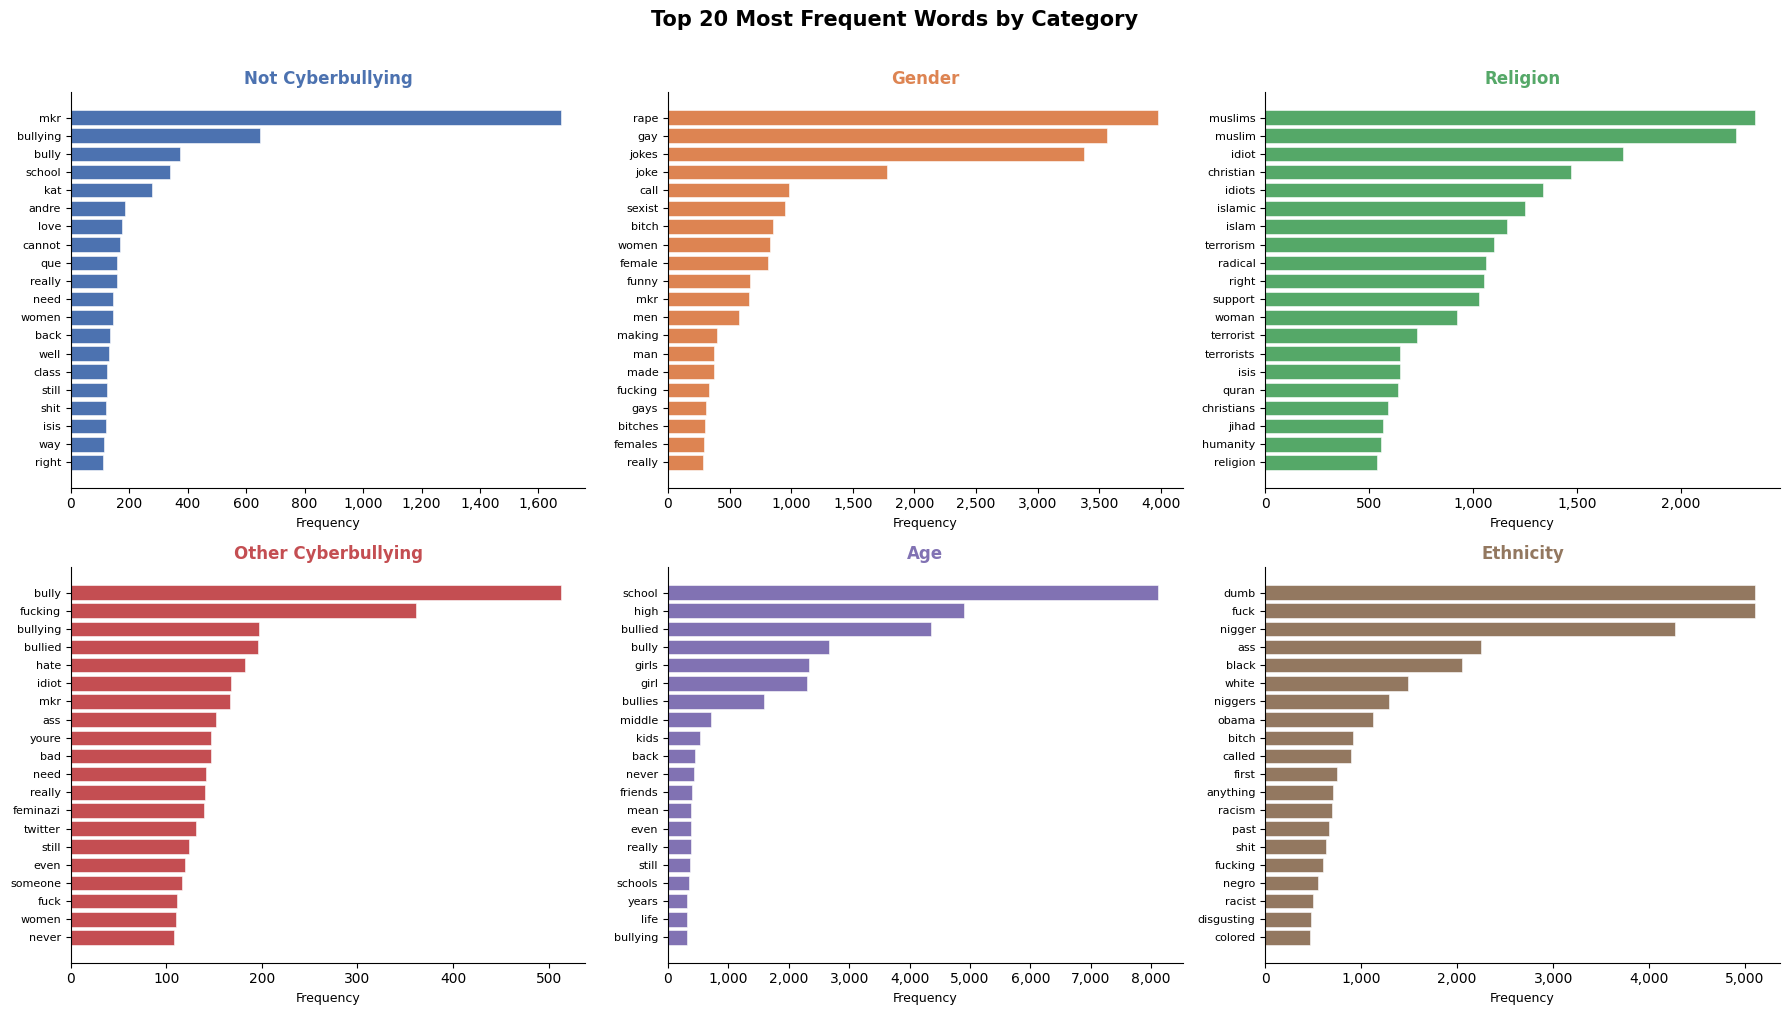

<Figure size 640x480 with 0 Axes>

In [33]:
def filter_tokens(token_list):
    return [ t for t in token_list if t not in STOPWORDS and len(t) > 2 and not t.isnumeric() and t not in {"user", "url", "http", "https", "<user>"} and not t.startswith("#") ]
df["filtered_tokens"] = df["tokens"].apply(filter_tokens)
df["token_count"] = df["filtered_tokens"].apply(len)
N_TOP = 20
cat_vocabs = {}
for cat in CATEGORIES:
    tokens = [t for tl in df.loc[df["cyberbullying_type"] == cat, "filtered_tokens"] for t in tl]
    cat_vocabs[cat] = Counter(tokens)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, cat in zip(axes, CATEGORIES):
    top_words = cat_vocabs[cat].most_common(N_TOP)
    words, counts = zip(*top_words)
    bars = ax.barh(list(words)[::-1], list(counts)[::-1], color=CATEGORY_PALETTE[cat], edgecolor="white", linewidth=0.4)
    ax.set_title(cat.replace("_", " ").title(), fontsize=12, fontweight="bold", color=CATEGORY_PALETTE[cat])
    ax.set_xlabel("Frequency", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines[["top","right"]].set_visible(False)


plt.suptitle(f"Top {N_TOP} Most Frequent Words by Category", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("bow_top_words_per_category.png", dpi=150, bbox_inches="tight")
plt.show()


def top_n_vocab(cat, n=500):
    return set(w for w, _ in cat_vocabs[cat].most_common(n))


for cat in CATEGORIES:
    subset = df.loc[df["cyberbullying_type"] == cat, "token_count"]
    axes[0].hist(subset, bins=40, alpha=0.5, label=cat.replace("_", " "), color=CATEGORY_PALETTE[cat], density=True)
axes[0].set_xlabel("Token Count (filtered)", fontsize=11)


axes[0].set_ylabel("Density", fontsize=11)
axes[0].set_title("Token Length Distribution by Category", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].spines[["top","right"]].set_visible(False)
bp_data = [df.loc[df["cyberbullying_type"] == cat, "token_count"].values for cat in CATEGORIES]
bp = axes[1].boxplot(bp_data, patch_artist=True, notch=True, medianprops=dict(color="white", linewidth=2))

for patch, cat in zip(bp["boxes"], CATEGORIES):
    patch.set_facecolor(CATEGORY_PALETTE[cat])
axes[1].set_xticklabels([c.replace("_", "\n") for c in CATEGORIES], fontsize=8)


axes[1].set_ylabel("Token Count (filtered)", fontsize=11)
axes[1].set_title("Token Count Boxplot by Category", fontsize=12, fontweight="bold")
axes[1].spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("bow_token_length_dist.png", dpi=150, bbox_inches="tight")
plt.show()

### Naive Bayes Analysis

In [34]:
y = df["cyberbullying_type"].values
le = LabelEncoder()
y_enc = le.fit_transform(y)
CLASS_NAMES = le.classes_.tolist()
N_CLASSES = len(CLASS_NAMES)

print(f"Classes ({N_CLASSES}): {CLASS_NAMES}")

X_text_train, X_text_test, y_train, y_test = train_test_split(
    df["clean_text"], y_enc, test_size=0.2, random_state=42, stratify=y_enc)

bow_vectorizer = CountVectorizer(
    max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)

X_train_bow = bow_vectorizer.fit_transform(X_text_train)
X_test_bow = bow_vectorizer.transform(X_text_test)

print(f"Train: {X_train_bow.shape[0]:,}  |  Test: {X_test_bow.shape[0]:,}")

models = { "MultinomialNB (BoW)": (MultinomialNB(alpha=1.0), X_train_bow, X_test_bow), "ComplementNB (BoW)": (ComplementNB(alpha=1.0), X_train_bow, X_test_bow),}

# TF-IDF vectorization for Naive Bayes
tfidf_vectorizer_nb = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95
)

X_train_tfidf = tfidf_vectorizer_nb.fit_transform(X_text_train)
X_test_tfidf  = tfidf_vectorizer_nb.transform(X_text_test)

# Add TF-IDF models to the comparison
tfidf_models = {
    "MultinomialNB (TF-IDF)": (MultinomialNB(alpha=1.0),  X_train_tfidf, X_test_tfidf),
    "ComplementNB (TF-IDF)":  (ComplementNB(alpha=1.0),   X_train_tfidf, X_test_tfidf),
}

results = {}



Classes (6): ['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion']
Train: 36,205  |  Test: 9,052


In [35]:
for name, (clf, X_tr, X_te) in tfidf_models.items():
    clf.fit(X_tr, y_train)
    y_pred  = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)

    acc         = accuracy_score(y_test, y_pred)
    f1_macro    = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    y_test_bin  = label_binarize(y_test, classes=list(range(N_CLASSES)))
    auc         = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="macro")

    results[name] = {
        "clf": clf, "y_pred": y_pred, "y_proba": y_proba,
        "accuracy": acc, "f1_macro": f1_macro,
        "f1_weighted": f1_weighted, "roc_auc": auc,
    }

    print(f"\n{'─'*55}")
    print(f" {name}")
    print(f" Accuracy: {acc:.4f} . F1 Macro: {f1_macro:.4f}")
    print(f" F1 Weighted: {f1_weighted:.4f} . ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))




───────────────────────────────────────────────────────
 MultinomialNB (TF-IDF)
 Accuracy: 0.7840 . F1 Macro: 0.7645
 F1 Weighted: 0.7765 . ROC-AUC: 0.9596
                     precision    recall  f1-score   support

                age       0.86      0.95      0.90      1587
          ethnicity       0.90      0.90      0.90      1577
             gender       0.88      0.78      0.83      1541
  not_cyberbullying       0.59      0.61      0.60      1556
other_cyberbullying       0.59      0.42      0.49      1198
           religion       0.80      0.95      0.87      1593

           accuracy                           0.78      9052
          macro avg       0.77      0.77      0.76      9052
       weighted avg       0.78      0.78      0.78      9052


───────────────────────────────────────────────────────
 ComplementNB (TF-IDF)
 Accuracy: 0.7728 . F1 Macro: 0.7426
 F1 Weighted: 0.7552 . ROC-AUC: 0.9595
                     precision    recall  f1-score   support

            

In [36]:
for name, (clf, X_tr, X_te) in models.items():
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))
    auc = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="macro")

    results[name] = {
        "clf": clf, "y_pred": y_pred, "y_proba": y_proba,
        "accuracy": acc, "f1_macro": f1_macro,
        "f1_weighted": f1_weighted, "roc_auc": auc,
    }
    print(f" {name}")
    print(f" Accuracy: {acc:.4f} . F1 Macro: {f1_macro:.4f}")
    print(f" F1 Weighted: {f1_weighted:.4f} . ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


 MultinomialNB (BoW)
 Accuracy: 0.7905 . F1 Macro: 0.7793
 F1 Weighted: 0.7894 . ROC-AUC: 0.9596
                     precision    recall  f1-score   support

                age       0.87      0.95      0.91      1587
          ethnicity       0.92      0.92      0.92      1577
             gender       0.92      0.74      0.82      1541
  not_cyberbullying       0.60      0.59      0.60      1556
other_cyberbullying       0.55      0.55      0.55      1198
           religion       0.84      0.92      0.88      1593

           accuracy                           0.79      9052
          macro avg       0.78      0.78      0.78      9052
       weighted avg       0.79      0.79      0.79      9052

 ComplementNB (BoW)
 Accuracy: 0.7608 . F1 Macro: 0.7235
 F1 Weighted: 0.7378 . ROC-AUC: 0.9576
                     precision    recall  f1-score   support

                age       0.74      0.98      0.85      1587
          ethnicity       0.86      0.95      0.90      1577
          

In [37]:
print("\nNaive Bayes Results Summary (BoW + TF-IDF)")
summary_rows = []
for name, v in results.items():
    summary_rows.append({
        "Model":       name,
        "Accuracy":    f"{v['accuracy']:.4f}",
        "F1 Macro":    f"{v['f1_macro']:.4f}",
        "F1 Weighted": f"{v['f1_weighted']:.4f}",
        "ROC-AUC":     f"{v['roc_auc']:.4f}"
    })
print(pd.DataFrame(summary_rows).to_string(index=False))


Naive Bayes Results Summary (BoW + TF-IDF)
                 Model Accuracy F1 Macro F1 Weighted ROC-AUC
MultinomialNB (TF-IDF)   0.7840   0.7645      0.7765  0.9596
 ComplementNB (TF-IDF)   0.7728   0.7426      0.7552  0.9595
   MultinomialNB (BoW)   0.7905   0.7793      0.7894  0.9596
    ComplementNB (BoW)   0.7608   0.7235      0.7378  0.9576


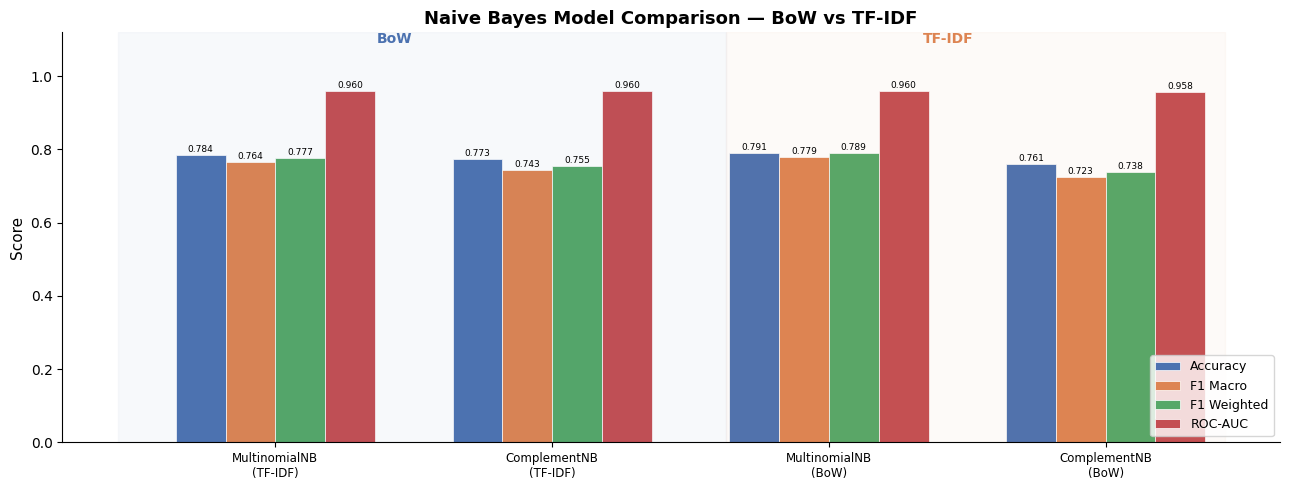

In [38]:
all_models = {
    "MultinomialNB\n(BoW)":    results["MultinomialNB (BoW)"],
    "ComplementNB\n(BoW)":     results["ComplementNB (BoW)"],
    "MultinomialNB\n(TF-IDF)": results["MultinomialNB (TF-IDF)"],
    "ComplementNB\n(TF-IDF)":  results["ComplementNB (TF-IDF)"],
}

metrics_df = pd.DataFrame([
    {
        "Model":       k,
        "Accuracy":    v["accuracy"],
        "F1 Macro":    v["f1_macro"],
        "F1 Weighted": v["f1_weighted"],
        "ROC-AUC":     v["roc_auc"]
    }
    for k, v in results.items()
])

fig, ax = plt.subplots(figsize=(13, 5))
x           = np.arange(len(metrics_df))
width       = 0.18
metric_cols = ["Accuracy", "F1 Macro", "F1 Weighted", "ROC-AUC"]
metric_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, (col, color) in enumerate(zip(metric_cols, metric_colors)):
    bars = ax.bar(x + i * width, metrics_df[col], width, label=col,
                  color=color, edgecolor="white", linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=6.5)


x_labels = [m.replace(" (", "\n(") for m in metrics_df["Model"]]
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(x_labels, fontsize=8.5)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Naive Bayes Model Comparison — BoW vs TF-IDF", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)


n_models = len(metrics_df)
mid = n_models / 2
ax.axvspan(-0.3, mid - 0.1,        alpha=0.04, color="#4C72B0", label="_BoW region")
ax.axvspan(mid - 0.1, n_models - 0.3, alpha=0.04, color="#DD8452", label="_TF-IDF region")
ax.text(mid / 2 - 0.3,        1.09, "BoW",    ha="center", fontsize=10, color="#4C72B0", fontweight="bold")
ax.text(mid + mid / 2 - 0.3,  1.09, "TF-IDF", ha="center", fontsize=10, color="#DD8452", fontweight="bold")

plt.tight_layout()
plt.savefig("nb_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


Best model: MultinomialNB (BoW) (F1 Macro = 0.7793)


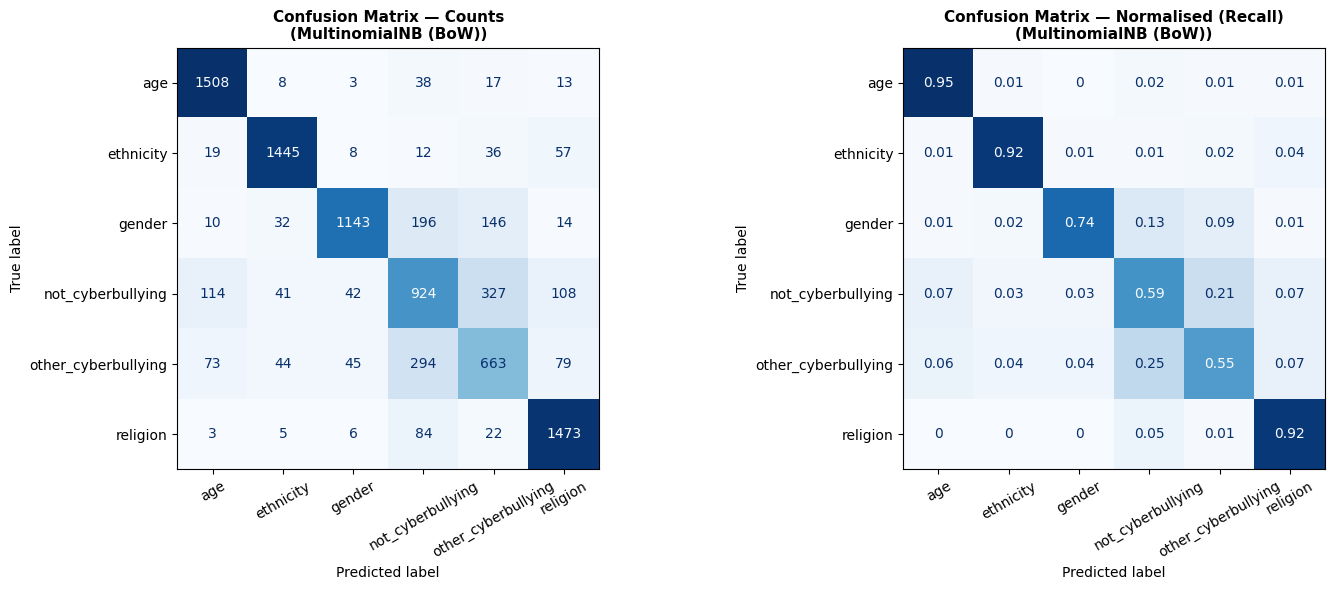

In [39]:
best_name = max(results, key=lambda k: results[k]["f1_macro"])
best = results[best_name]
print(f"Best model: {best_name} (F1 Macro = {best['f1_macro']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm_raw = confusion_matrix(y_test, best["y_pred"])
ConfusionMatrixDisplay(cm_raw, display_labels=CLASS_NAMES).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — Counts\n({best_name})", fontsize=11, fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=CLASS_NAMES).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Confusion Matrix — Normalised (Recall)\n({best_name})", fontsize=11, fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("nb_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

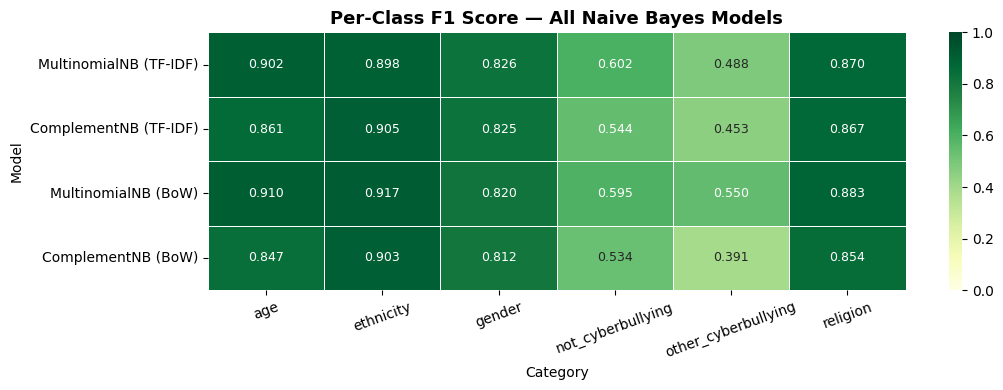

Top 15 Predictive Features per Class (MultinomialNB (BoW)) 


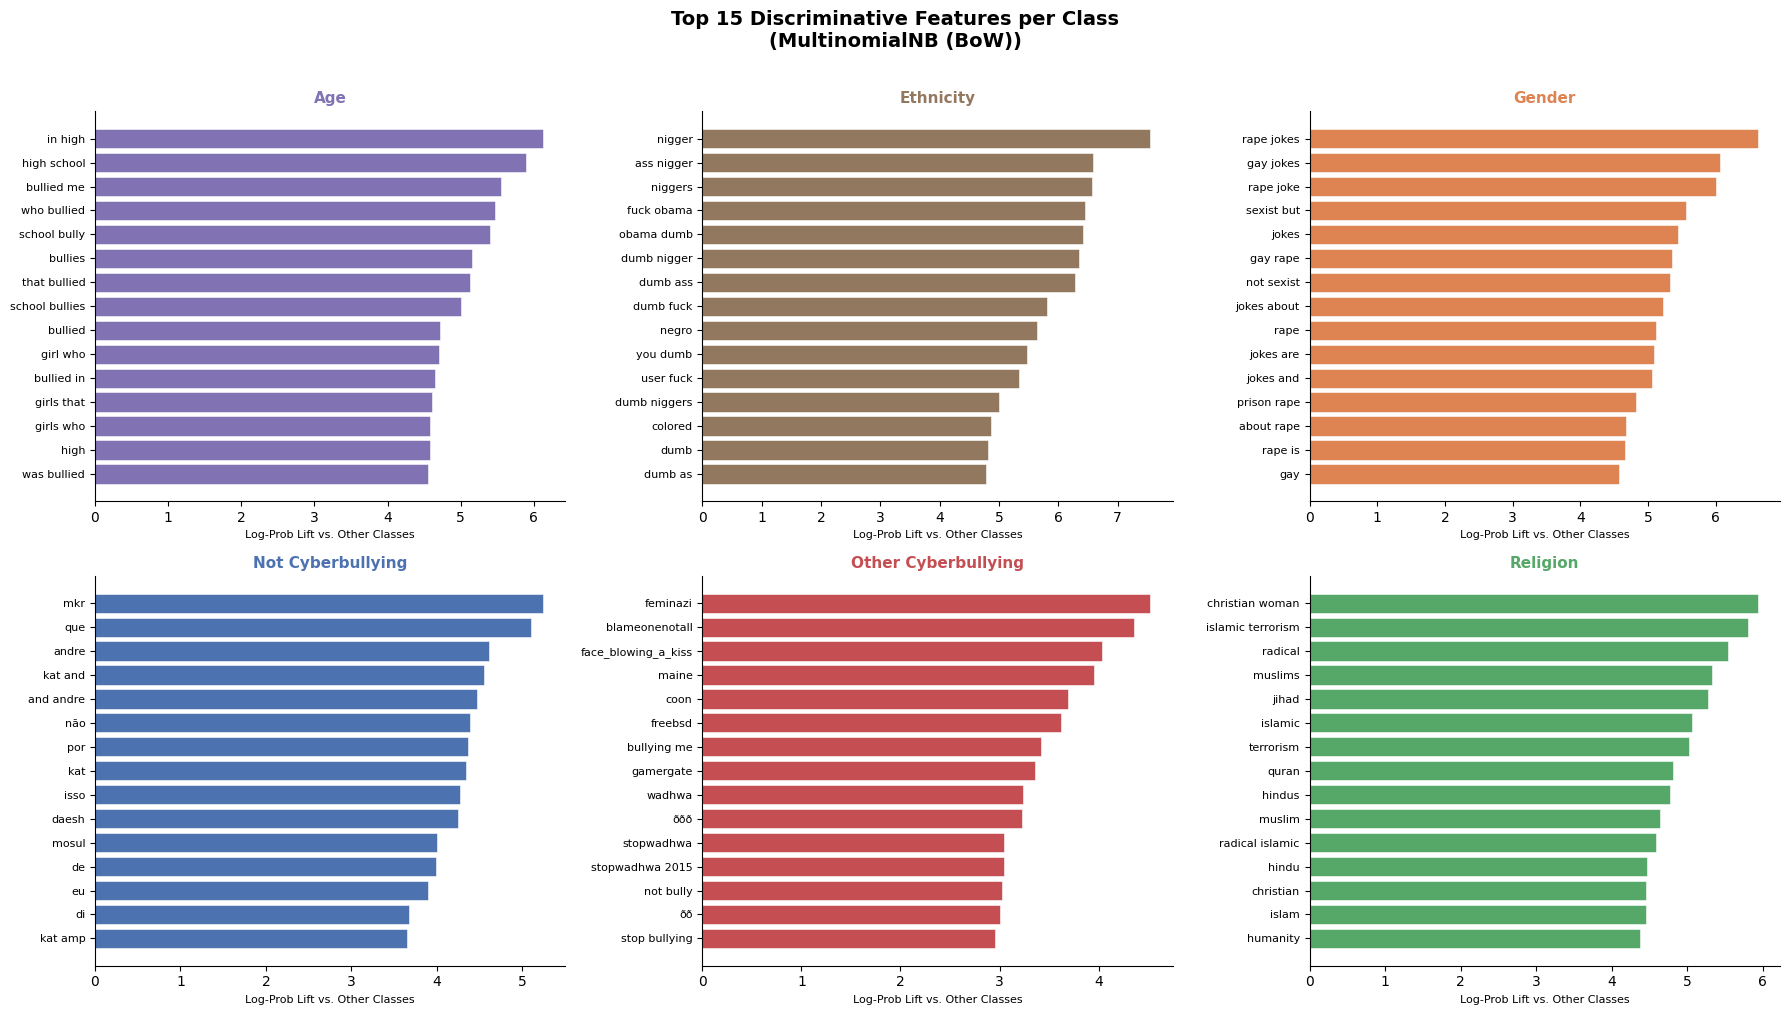

In [40]:
f1_per_class = {}
for name, v in results.items():
    report = classification_report(y_test, v["y_pred"], target_names=CLASS_NAMES, output_dict=True)
    f1_per_class[name] = {cls: report[cls]["f1-score"] for cls in CLASS_NAMES}

f1_df = pd.DataFrame(f1_per_class).T

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(f1_df, annot=True, fmt=".3f", cmap="YlGn", linewidths=0.5, ax=ax, vmin=0, vmax=1, annot_kws={"size": 9})
ax.set_title("Per-Class F1 Score — All Naive Bayes Models", fontsize=13, fontweight="bold")
ax.set_xlabel("Category", fontsize=10)
ax.set_ylabel("Model", fontsize=10)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("nb_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Top 15 Predictive Features per Class ({best_name}) ")
clf_best = best["clf"]
feature_names = bow_vectorizer.get_feature_names_out()
log_probs = clf_best.feature_log_prob_

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (ax, cls) in enumerate(zip(axes, CLASS_NAMES)):
    other_idx = [j for j in range(N_CLASSES) if j != i]
    diff_scores = log_probs[i] - log_probs[other_idx].mean(axis=0)
    top_idx = diff_scores.argsort()[::-1][:15]
    top_words = feature_names[top_idx]
    top_scores = diff_scores[top_idx]

    color = CATEGORY_PALETTE.get(cls, "#888888")
    ax.barh(list(top_words)[::-1], list(top_scores)[::-1], color=color, edgecolor="white", linewidth=0.4)
    ax.set_title(cls.replace("_", " ").title(), fontsize=11, fontweight="bold", color=color)
    ax.set_xlabel("Log-Prob Lift vs. Other Classes", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Top 15 Discriminative Features per Class\n({best_name})", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("nb_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

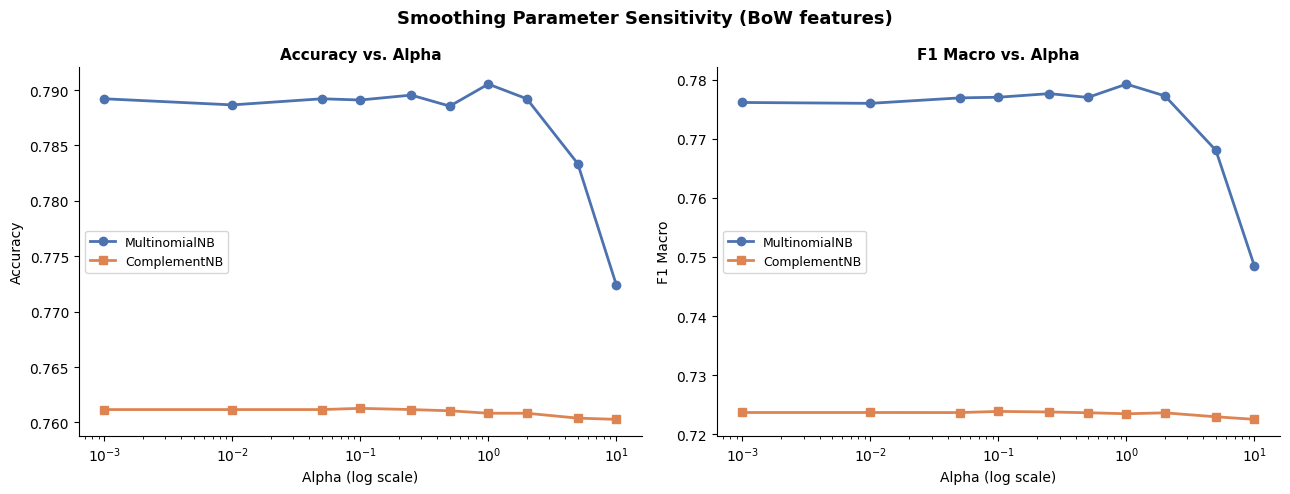

In [41]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
alpha_results = {"alpha": alphas, "MNB_acc": [], "CNB_acc": [], "MNB_f1": [], "CNB_f1": []}

for alpha in alphas:
    for ModelClass, acc_key, f1_key in [(MultinomialNB, "MNB_acc", "MNB_f1"), (ComplementNB, "CNB_acc", "CNB_f1")]:
        clf = ModelClass(alpha=alpha)
        clf.fit(X_train_bow, y_train)
        yp = clf.predict(X_test_bow)
        alpha_results[acc_key].append(accuracy_score(y_test, yp))
        alpha_results[f1_key].append(f1_score(y_test, yp, average="macro"))

alpha_df = pd.DataFrame(alpha_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in [
    (axes[0], ("MNB_acc", "CNB_acc"), "Accuracy vs. Alpha"),
    (axes[1], ("MNB_f1", "CNB_f1"), "F1 Macro vs. Alpha"),
]:
    ax.plot(alphas, alpha_df[metric[0]], marker="o", label="MultinomialNB", color="#4C72B0", linewidth=2)
    ax.plot(alphas, alpha_df[metric[1]], marker="s", label="ComplementNB", color="#DD8452", linewidth=2)
    ax.set_xscale("log")
    ax.set_xlabel("Alpha (log scale)", fontsize=10)
    ax.set_ylabel(title.split(" vs.")[0], fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Smoothing Parameter Sensitivity (BoW features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("nb_alpha_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

In [42]:
best_is_cnb = "Complement" in best_name
ModelClass_cv = ComplementNB if best_is_cnb else MultinomialNB

nb_pipeline = Pipeline([ ("bow", CountVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)), ("nb", ModelClass_cv(alpha=1.0)) ])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_cv_pred = cross_val_predict(nb_pipeline, df["clean_text"], y_enc, cv=skf)

cv_acc = accuracy_score(y_enc, y_cv_pred)
cv_f1 = f1_score(y_enc, y_cv_pred, average="macro")

print(f"5-Fold CV — {best_name}")
print(f" Accuracy : {cv_acc:.4f}")
print(f" F1 Macro : {cv_f1:.4f}")
print(classification_report(y_enc, y_cv_pred, target_names=CLASS_NAMES))

print("Naive Bayes Results Summary")
summary_rows = []
for name, v in results.items():
    summary_rows.append({"Model": name, "Accuracy": f"{v['accuracy']:.4f}", "F1 Macro": f"{v['f1_macro']:.4f}", "F1 Weighted": f"{v['f1_weighted']:.4f}", "ROC-AUC": f"{v['roc_auc']:.4f}"})
print(pd.DataFrame(summary_rows).to_string(index=False))

5-Fold CV — MultinomialNB (BoW)
 Accuracy : 0.7860
 F1 Macro : 0.7746
                     precision    recall  f1-score   support

                age       0.87      0.95      0.91      7936
          ethnicity       0.92      0.92      0.92      7885
             gender       0.91      0.73      0.81      7703
  not_cyberbullying       0.58      0.57      0.57      7781
other_cyberbullying       0.54      0.56      0.55      5988
           religion       0.85      0.92      0.89      7964

           accuracy                           0.79     45257
          macro avg       0.78      0.78      0.77     45257
       weighted avg       0.79      0.79      0.78     45257

Naive Bayes Results Summary
                 Model Accuracy F1 Macro F1 Weighted ROC-AUC
MultinomialNB (TF-IDF)   0.7840   0.7645      0.7765  0.9596
 ComplementNB (TF-IDF)   0.7728   0.7426      0.7552  0.9595
   MultinomialNB (BoW)   0.7905   0.7793      0.7894  0.9596
    ComplementNB (BoW)   0.7608   0.7235     